# 3D Molecular Representations


In chemistry, molecules are not flat drawings — they exist in **3D space**. Every atom has a real x, y, z position, and those positions determine how a drug molecule fits into a protein target (like a key into a lock).

A **3D conformer** is one specific spatial arrangement of atoms in a molecule. The same molecule can have many conformers — think of a flexible chain bending into different shapes.

**By the end of this notebook, we will:**
- Parse 5 real drug molecules from SMILES strings
- Generate valid 3D conformers using the ETKDG algorithm
- Extract coordinate matrices — the (N_atoms × 3) arrays that feed directly into 3D neural networks
- Visualize each molecule in 3D space
- Compute and validate bond lengths against known experimental values
- Save the coordinate arrays for future ML notebooks

> **Why does 3D matter for AI?** In Month 8 of this roadmap, we will build E(n)-Equivariant Graph Neural Networks (EGNNs) that take these exact coordinate arrays as input. The model must learn that rotating a molecule in space cannot change its energy — a property called *rotational invariance*.

In [1]:
# Core cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole

# Numerical computing
import numpy as np
from scipy.spatial.distance import cdist

# Visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Utilities
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Choosing Our 5 Drug Molecules

We'll work with 5 real drugs chosen to span a range of structural complexity:

| Drug | SMILES | Why interesting |
|---|---|---|
| **Aspirin** | `CC(=O)Oc1ccccc1C(=O)O` | Simple, aromatic — a good baseline |
| **Caffeine** | `Cn1cnc2c1c(=O)n(C)c(=O)n2C` | Fused ring system — compact and flat |
| **Ibuprofen** | `CC(C)Cc1ccc(cc1)C(C)C(=O)O` | Flexible aliphatic chain |
| **Paracetamol** | `CC(=O)Nc1ccc(O)cc1` | Classic drug-like, simple para-substituted ring |
| **Dopamine** | `NCCc1ccc(O)c(O)c1` | Neurotransmitter — two –OH groups, flexible side chain |

**What is SMILES?**  
SMILES (Simplified Molecular Input Line Entry System) is a text notation that encodes molecular structure. `O` = water, `CC` = ethane, lowercase letters = aromatic atoms. A single string completely describes a molecule's connectivity — but not its 3D shape. That's what we're about to compute.

In [2]:
# Define our 5 drug molecules as a name → SMILES dictionary
molecules_smiles = {
    "Aspirin":     "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine":    "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Ibuprofen":   "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Dopamine":    "NCCc1ccc(O)c(O)c1"
}

print(f"Defined {len(molecules_smiles)} molecules:")
for name, smiles in molecules_smiles.items():
    print(f"  {name:<14}: {smiles}")

Defined 5 molecules:
  Aspirin       : CC(=O)Oc1ccccc1C(=O)O
  Caffeine      : Cn1cnc2c1c(=O)n(C)c(=O)n2C
  Ibuprofen     : CC(C)Cc1ccc(cc1)C(C)C(=O)O
  Paracetamol   : CC(=O)Nc1ccc(O)cc1
  Dopamine      : NCCc1ccc(O)c(O)c1


## Parsing SMILES & Adding Hydrogens

Two steps happen here:

**1. `Chem.MolFromSmiles()`** — Parses the SMILES text string into RDKit's internal molecular graph object. Atoms become nodes, bonds become edges. This is the 2D graph representation.

**2. `Chem.AddHs()`** — By default, RDKit represents hydrogens *implicitly* (they're assumed but not stored). For 3D conformer generation, we must add them **explicitly** because hydrogen positions affect bond angles and overall molecular geometry.

After adding hydrogens, the atom count jumps significantly:  
- Aspirin: 13 heavy atoms → ~21 atoms with explicit H  
- Caffeine: 14 heavy atoms → ~24 atoms with explicit H  

This matters for the shape of our eventual coordinate matrix.

In [4]:
# Parse SMILES and add explicit hydrogens
mols_dict = {}

for name, smiles in molecules_smiles.items():
    # Step 1: parse SMILES → RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        print(f"ERROR: Could not parse SMILES for {name}")
        continue
    
    heavy_atom_count = mol.GetNumAtoms()
    
    # Step 2: add explicit hydrogens
    mol = Chem.AddHs(mol)
    total_atom_count = mol.GetNumAtoms()
    
    mols_dict[name] = mol
    print(f"{name:<14}: {heavy_atom_count} heavy atoms → {total_atom_count} atoms with H")

print(f"\nSuccessfully parsed {len(mols_dict)} molecules.")

Aspirin       : 13 heavy atoms → 21 atoms with H
Caffeine      : 14 heavy atoms → 24 atoms with H
Ibuprofen     : 15 heavy atoms → 33 atoms with H
Paracetamol   : 11 heavy atoms → 20 atoms with H
Dopamine      : 11 heavy atoms → 22 atoms with H

Successfully parsed 5 molecules.


## Generating 3D Conformers — What Is ETKDG?

This is the core step. We are asking: *"where in 3D space should each atom be placed?"*

**ETKDG** (Experimental Torsion Knowledge Distance Geometry) works in two stages:
1. **Distance Geometry**: Places atoms so that pairwise distances satisfy bond length and angle constraints, using a random embedding into 3D space.
2. **Torsion Correction**: Corrects dihedral angles using a database compiled from real crystal structures — so the result reflects physically observed molecular geometries.

**MMFF94** (Merck Molecular Force Field 1994) then refines the structure by minimizing its potential energy — it pushes atoms toward positions where the sum of all forces (bond stretching, angle bending, torsional, van der Waals) is minimized.

The result is one **local energy minimum** — a valid, chemically reasonable 3D structure.

> In real drug discovery pipelines, hundreds of conformers are generated per molecule to sample the conformational space. For this exercise, one is sufficient.

In [5]:
# Generate 3D conformers using ETKDG + MMFF94 optimization
import random
random.seed(42)  # for reproducibility

for name, mol in mols_dict.items():
    # Step 1: embed molecule — place atoms in 3D using ETKDG
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    result = AllChem.EmbedMolecule(mol, params)
    
    if result == -1:
        print(f"FAILED to embed {name}")
        continue
    
    # Step 2: optimize geometry with MMFF94 force field
    ff_result = AllChem.MMFFOptimizeMolecule(mol)
    
    status = "optimized" if ff_result == 0 else "not converged (still usable)"
    print(f"{name:<14}: 3D conformer generated and {status}")

print("\nConformer generation complete.")

Aspirin       : 3D conformer generated and optimized
Caffeine      : 3D conformer generated and optimized
Ibuprofen     : 3D conformer generated and optimized
Paracetamol   : 3D conformer generated and optimized
Dopamine      : 3D conformer generated and optimized

Conformer generation complete.


## Extracting the Coordinate Matrix

`mol.GetConformer().GetPositions()` returns a NumPy array of shape **(N_atoms, 3)**.

- Each **row** = one atom
- The three **columns** = x, y, z position in **Ångströms** (1 Å = 10⁻¹⁰ meters)

This matrix **is** the 3D molecular representation. In Month 8, when we build E(n)-Equivariant GNNs, these exact arrays are what the model receives as node positions.

**Important:** The origin (0, 0, 0) is arbitrary — RDKit places the molecule somewhere in space, but there is no meaningful absolute reference frame. What matters is the **relative positions** between atoms: the distances and angles encode all the chemistry.

In [6]:
# Extract 3D coordinate matrices from all conformers
coords_dict = {}

for name, mol in mols_dict.items():
    coords = mol.GetConformer().GetPositions()  # returns (N_atoms, 3) numpy array
    coords_dict[name] = coords
    print(f"{name:<14}: coordinate matrix shape = {coords.shape}")

# Inspect Aspirin's coordinate matrix in detail
print("\n--- Aspirin coordinate matrix (first 8 rows) ---")
print(f"{'Atom Idx':<10} {'x (Å)':<12} {'y (Å)':<12} {'z (Å)'}")
print("-" * 46)

aspirin_mol = mols_dict["Aspirin"]
aspirin_coords = coords_dict["Aspirin"]

for i, (row, atom) in enumerate(zip(aspirin_coords[:8], aspirin_mol.GetAtoms())):
    symbol = atom.GetSymbol()
    print(f"{i:<4} ({symbol:<2})    {row[0]:>10.4f}   {row[1]:>10.4f}   {row[2]:>10.4f}")

Aspirin       : coordinate matrix shape = (21, 3)
Caffeine      : coordinate matrix shape = (24, 3)
Ibuprofen     : coordinate matrix shape = (33, 3)
Paracetamol   : coordinate matrix shape = (20, 3)
Dopamine      : coordinate matrix shape = (22, 3)

--- Aspirin coordinate matrix (first 8 rows) ---
Atom Idx   x (Å)        y (Å)        z (Å)
----------------------------------------------
0    (C )       -2.5958      -2.2697       0.0673
1    (C )       -1.7184      -1.1372      -0.3750
2    (O )       -1.5682      -0.7921      -1.5401
3    (O )       -1.1429      -0.5497       0.7462
4    (C )       -0.2352       0.4612       0.4167
5    (C )       -0.6985       1.7777       0.5090
6    (C )        0.1638       2.8340       0.2219
7    (C )        1.4845       2.5752      -0.1434


## Coloring Atoms by Element (CPK Convention)

In chemistry, there is a standard color convention called **CPK coloring** (named after Corey, Pauling, and Koltun):

| Element | Color | Reason |
|---|---|---|
| Carbon (C) | Grey | Most common backbone atom |
| Oxygen (O) | Red | Electronegative, often involved in hydrogen bonds |
| Nitrogen (N) | Blue | Key in amines, amides, heterocycles |
| Hydrogen (H) | White / Light grey | Smallest atom |
| Sulfur (S) | Yellow | Distinctive color in biology |

We loop through `mol.GetAtoms()` to retrieve each atom's element symbol, then map it to a color for the 3D scatter plot.

In [7]:
# Helper: returns a list of CPK colors for each atom in a molecule
def get_atom_colors(mol):
    cpk_colors = {
        'C': '#808080',   # grey
        'O': '#FF0000',   # red
        'N': '#0000FF',   # blue
        'H': '#D3D3D3',   # light grey
        'S': '#FFD700',   # gold/yellow
        'P': '#FFA500',   # orange
        'F': '#00FF00',   # green
        'Cl': '#00FF00',  # green
        'Br': '#8B0000',  # dark red
    }
    default_color = '#FF69B4'  # pink for anything else
    
    colors = []
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        colors.append(cpk_colors.get(symbol, default_color))
    
    return colors

# Helper: returns atom sizes for scatter plot (heavier atoms = bigger dot)
def get_atom_sizes(mol):
    size_map = {'H': 20, 'C': 80, 'N': 80, 'O': 80, 'S': 100}
    default_size = 80
    return [size_map.get(atom.GetSymbol(), default_size) for atom in mol.GetAtoms()]

# Test on Aspirin
test_colors = get_atom_colors(mols_dict["Aspirin"])
print(f"Aspirin: {len(test_colors)} atom colors generated")
print(f"First 5 colors: {test_colors[:5]}")

Aspirin: 21 atom colors generated
First 5 colors: ['#808080', '#808080', '#FF0000', '#FF0000', '#808080']


## 3D Scatter Plots — Seeing Molecules in Space

Each point in the scatter plot below is **one atom**, positioned at its real x, y, z coordinates in Ångströms.

This is not a stylized chemical diagram — it is the actual 3D structure as computed by ETKDG + MMFF94.

**Things to notice:**
- **Caffeine** is flat (planar aromatic rings dominate, minimal z-variation)
- **Ibuprofen** has more depth due to its flexible aliphatic chain and tetrahedral carbons
- **Dopamine** shows the side chain extending away from the aromatic ring
- All molecules are roughly 5–10 Å across — typical for small drug molecules

These shape differences are exactly what distinguishes one drug from another in a protein binding pocket.

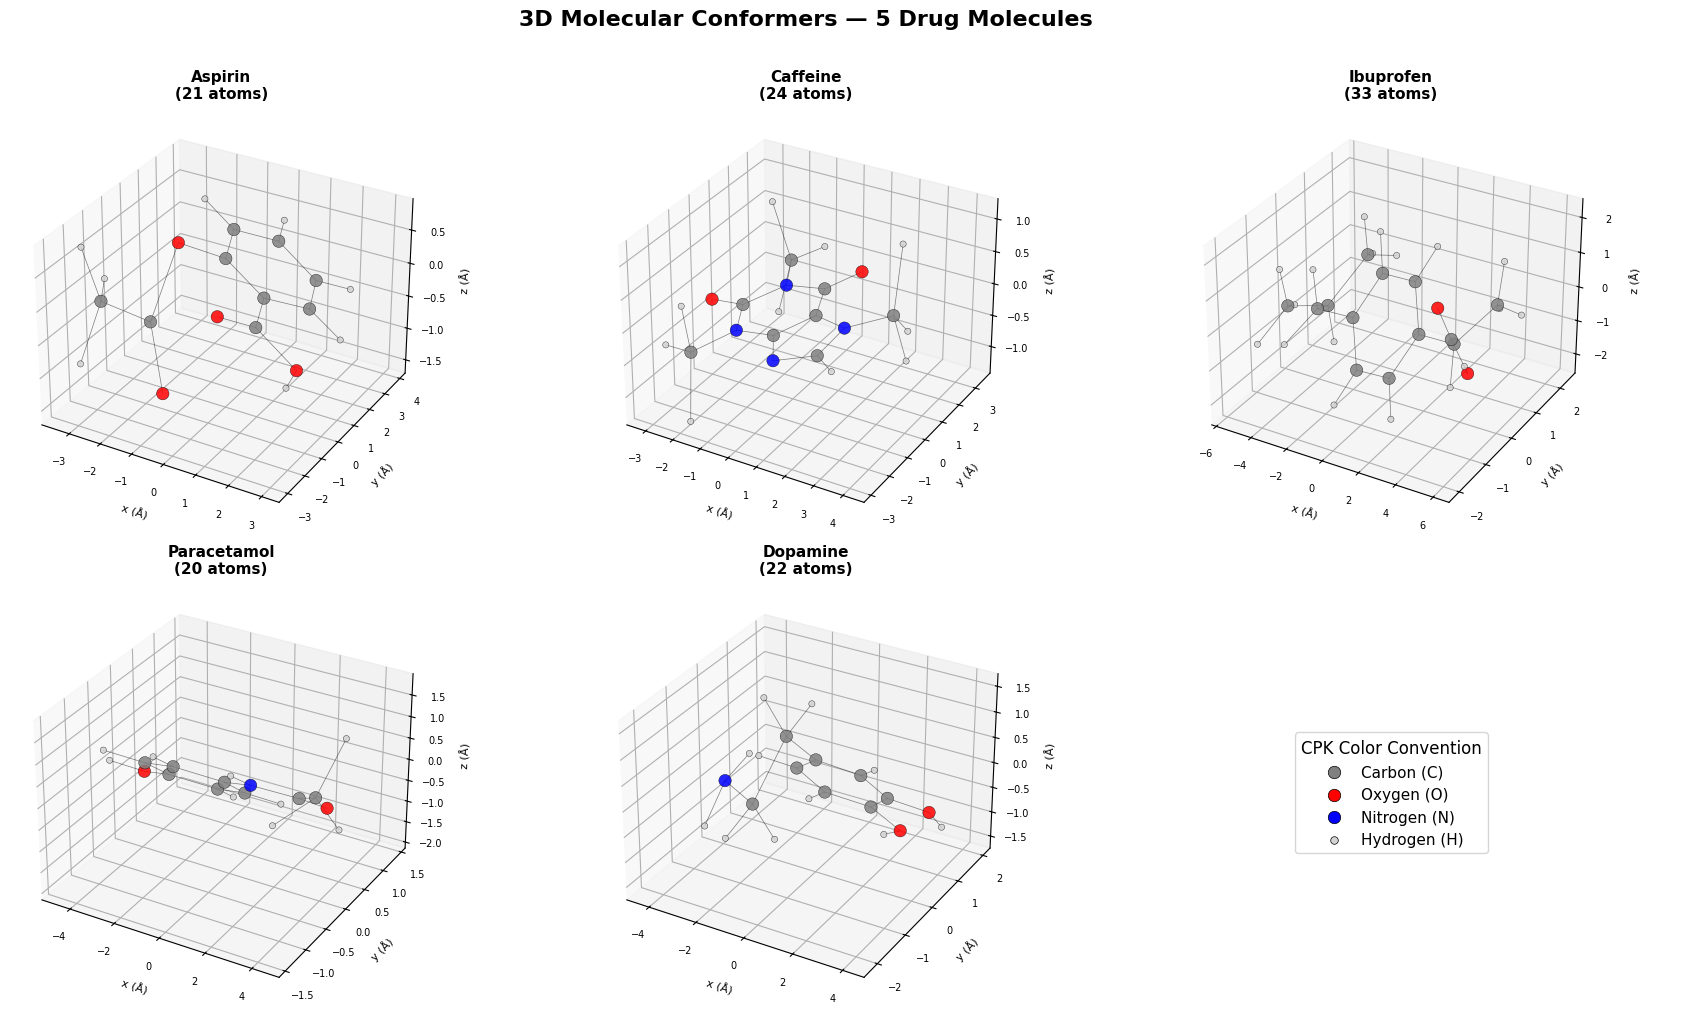

Saved: 3d_molecular_conformers.png


In [8]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('3D Molecular Conformers — 5 Drug Molecules', fontsize=16, fontweight='bold', y=1.01)

drug_names = list(mols_dict.keys())

for idx, name in enumerate(drug_names):
    mol = mols_dict[name]
    coords = coords_dict[name]
    colors = get_atom_colors(mol)
    sizes = get_atom_sizes(mol)
    
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    
    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    
    # Plot atoms as scatter points
    ax.scatter(x, y, z, c=colors, s=sizes, alpha=0.85, edgecolors='black', linewidths=0.3)
    
    # Draw bonds as lines
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        xi, yi, zi = coords[i]
        xj, yj, zj = coords[j]
        ax.plot([xi, xj], [yi, yj], [zi, zj], 'k-', linewidth=0.5, alpha=0.5)
    
    n_atoms = mol.GetNumAtoms()
    ax.set_title(f'{name}\n({n_atoms} atoms)', fontsize=11, fontweight='bold')
    ax.set_xlabel('x (Å)', fontsize=8)
    ax.set_ylabel('y (Å)', fontsize=8)
    ax.set_zlabel('z (Å)', fontsize=8)
    ax.tick_params(labelsize=7)

# Legend panel (6th subplot)
ax_legend = fig.add_subplot(2, 3, 6)
ax_legend.axis('off')
legend_elements = [
    plt.scatter([], [], c='#808080', s=80, label='Carbon (C)', edgecolors='black', linewidths=0.5),
    plt.scatter([], [], c='#FF0000', s=80, label='Oxygen (O)', edgecolors='black', linewidths=0.5),
    plt.scatter([], [], c='#0000FF', s=80, label='Nitrogen (N)', edgecolors='black', linewidths=0.5),
    plt.scatter([], [], c='#D3D3D3', s=30, label='Hydrogen (H)', edgecolors='black', linewidths=0.5),
]
ax_legend.legend(handles=legend_elements, loc='center', fontsize=11,
                 title='CPK Color Convention', title_fontsize=12, frameon=True)

plt.tight_layout()
plt.savefig('3d_molecular_conformers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 3d_molecular_conformers.png")

## The Distance Matrix — Encoding 3D Relationships

A coordinate matrix tells you *where* each atom is. A **distance matrix** tells you *how far* each atom is from every other atom.

It is an **(N_atoms × N_atoms)** symmetric matrix where entry `[i, j]` is the Euclidean distance between atom i and atom j.

**Key property: rotation invariance**  
If you rotate the entire molecule in space, all pairwise distances remain exactly the same. This is a foundational concept for equivariant neural networks: we want models whose *energy predictions* are invariant to rotation.

Properties of the distance matrix:
- **Diagonal** = 0 (distance from an atom to itself)
- **Symmetric**: distance(i→j) = distance(j→i)
- **Units**: Ångströms (Å)
- **Dark squares** in the heatmap = small distances (bonded or nearby atoms)  
- **Light squares** = large distances (atoms far apart in the molecule)

Distance matrix shape  : (21, 21)
Min distance (diagonal): 0.0000 Å  (should be 0.0)
Max distance           : 8.0601 Å
Is symmetric           : True


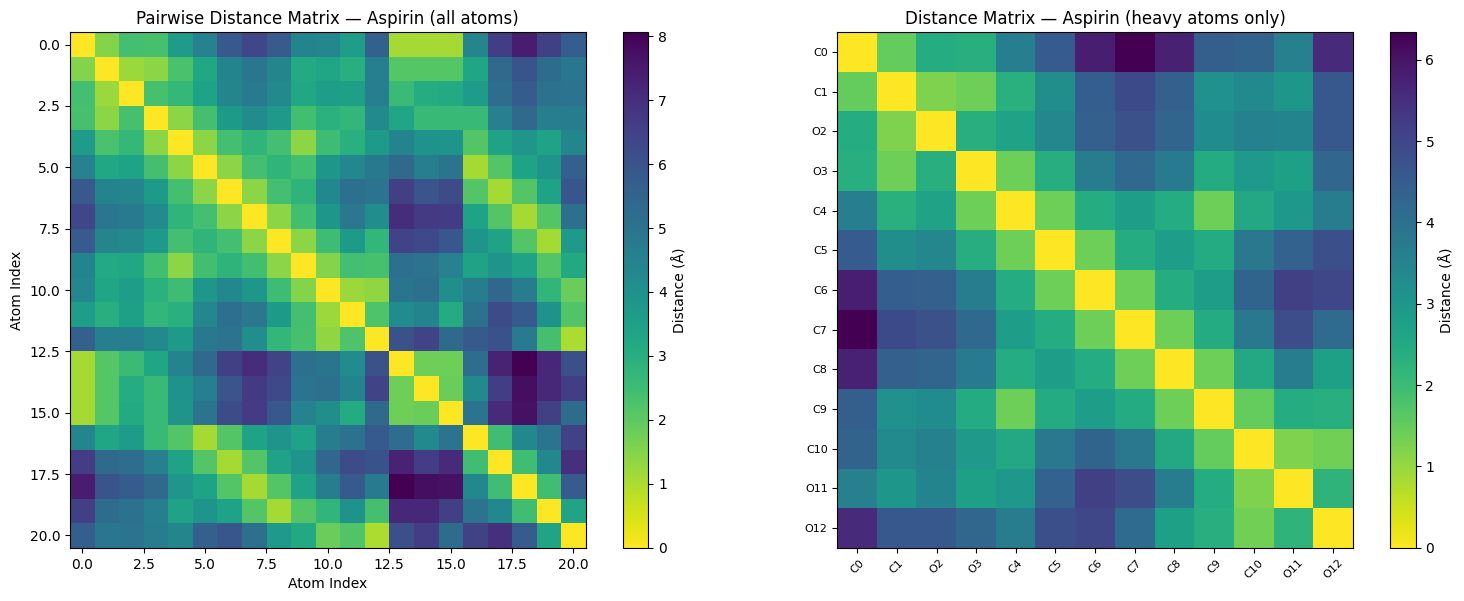

Saved: aspirin_distance_matrix.png


In [9]:
# Compute and visualize the pairwise distance matrix for Aspirin
aspirin_coords = coords_dict["Aspirin"]
aspirin_mol = mols_dict["Aspirin"]

# scipy's cdist computes all pairwise Euclidean distances efficiently
dist_matrix = cdist(aspirin_coords, aspirin_coords, metric='euclidean')

print(f"Distance matrix shape  : {dist_matrix.shape}")
print(f"Min distance (diagonal): {dist_matrix.min():.4f} Å  (should be 0.0)")
print(f"Max distance           : {dist_matrix.max():.4f} Å")
print(f"Is symmetric           : {np.allclose(dist_matrix, dist_matrix.T)}")

# Build atom labels for axis ticks
atom_labels = [f"{a.GetSymbol()}{i}" for i, a in enumerate(aspirin_mol.GetAtoms())]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full distance matrix
im1 = axes[0].imshow(dist_matrix, cmap='viridis_r')
plt.colorbar(im1, ax=axes[0], label='Distance (Å)')
axes[0].set_title('Pairwise Distance Matrix — Aspirin (all atoms)', fontsize=12)
axes[0].set_xlabel('Atom Index')
axes[0].set_ylabel('Atom Index')

# Right: heavy atoms only (no H) for clarity
heavy_indices = [i for i, a in enumerate(aspirin_mol.GetAtoms()) if a.GetSymbol() != 'H']
heavy_labels = [atom_labels[i] for i in heavy_indices]
heavy_dist = dist_matrix[np.ix_(heavy_indices, heavy_indices)]

im2 = axes[1].imshow(heavy_dist, cmap='viridis_r')
plt.colorbar(im2, ax=axes[1], label='Distance (Å)')
axes[1].set_title('Distance Matrix — Aspirin (heavy atoms only)', fontsize=12)
axes[1].set_xticks(range(len(heavy_labels)))
axes[1].set_xticklabels(heavy_labels, rotation=45, fontsize=8)
axes[1].set_yticks(range(len(heavy_labels)))
axes[1].set_yticklabels(heavy_labels, fontsize=8)

plt.tight_layout()
plt.savefig('aspirin_distance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: aspirin_distance_matrix.png")

## Bond Length Validation — Checking Our Chemistry

A conformer is only useful if it's **chemically correct**. We can verify this by measuring distances between bonded atoms and comparing to well-established experimental values:

| Bond Type | Expected Length | Source |
|---|---|---|
| C–C single | ~1.54 Å | Diamond, alkanes |
| C=C double | ~1.34 Å | Alkenes |
| C≡C triple | ~1.20 Å | Alkynes |
| C=O double | ~1.23 Å | Aldehydes, ketones |
| C–O single | ~1.43 Å | Alcohols, ethers |
| C–H | ~1.09 Å | Alkanes |
| O–H | ~0.96 Å | Alcohols, water |
| N–H | ~1.01 Å | Amines |
| C–N single | ~1.47 Å | Amines |
| C=N double | ~1.29 Å | Imines |

If our measured distances are close to these (within ~0.05 Å), the ETKDG + MMFF94 pipeline worked correctly. This kind of **sanity check is a core habit in computational chemistry** — never trust a conformer you haven't validated.

In [10]:
# Bond length validation for Aspirin
aspirin_mol = mols_dict["Aspirin"]
aspirin_coords = coords_dict["Aspirin"]

# Known reference bond lengths in Angstroms
reference_lengths = {
    ('C', 'C', 1.0): 1.54,
    ('C', 'C', 1.5): 1.40,  # aromatic
    ('C', 'C', 2.0): 1.34,
    ('C', 'O', 1.0): 1.43,
    ('C', 'O', 2.0): 1.23,
    ('C', 'H', 1.0): 1.09,
    ('O', 'H', 1.0): 0.96,
    ('C', 'N', 1.0): 1.47,
}

print(f"{'Bond':<10} {'Idx i':>6} {'Idx j':>6} {'Measured (Å)':>14} {'Expected (Å)':>14} {'Δ (Å)':>8} {'Status'}")
print("-" * 75)

for bond in aspirin_mol.GetBonds():
    i = bond.GetBeginAtomIdx()
    j = bond.GetEndAtomIdx()
    
    sym_i = aspirin_mol.GetAtomWithIdx(i).GetSymbol()
    sym_j = aspirin_mol.GetAtomWithIdx(j).GetSymbol()
    bond_order = bond.GetBondTypeAsDouble()
    
    # Euclidean distance from coordinate matrix
    measured = np.linalg.norm(aspirin_coords[i] - aspirin_coords[j])
    
    bond_label = f"{sym_i}–{sym_j}"
    key = (sym_i, sym_j, bond_order) if (sym_i, sym_j, bond_order) in reference_lengths \
          else (sym_j, sym_i, bond_order)
    
    expected = reference_lengths.get(key, None)
    
    if expected:
        delta = abs(measured - expected)
        status = "✓ OK" if delta < 0.05 else "⚠ CHECK"
        print(f"{bond_label:<10} {i:>6} {j:>6} {measured:>14.4f} {expected:>14.3f} {delta:>8.4f}  {status}")
    else:
        print(f"{bond_label:<10} {i:>6} {j:>6} {measured:>14.4f} {'N/A':>14} {'—':>8}")

print("\nAll measured bond lengths should be within ~0.05 Å of the expected values.")

Bond        Idx i  Idx j   Measured (Å)   Expected (Å)    Δ (Å) Status
---------------------------------------------------------------------------
C–C             0      1         1.4994          1.540   0.0406  ✓ OK
C–O             1      2         1.2244          1.230   0.0056  ✓ OK
C–O             1      3         1.3905          1.430   0.0395  ✓ OK
O–C             3      4         1.3980          1.430   0.0320  ✓ OK
C–C             4      5         1.3987          1.400   0.0013  ✓ OK
C–C             5      6         1.3935          1.400   0.0065  ✓ OK
C–C             6      7         1.3945          1.400   0.0055  ✓ OK
C–C             7      8         1.3988          1.400   0.0012  ✓ OK
C–C             8      9         1.4037          1.400   0.0037  ✓ OK
C–C             9     10         1.4867          1.540   0.0533  ⚠ CHECK
C–O            10     11         1.2172          1.230   0.0128  ✓ OK
C–O            10     12         1.3472          1.430   0.0828  ⚠ CHECK
C–C    

## Saving the Coordinate Matrices

We save these arrays now so future notebooks can load them directly as PyTorch tensors — no need to re-run conformer generation every time.

- **`.npy`** — one file per molecule, loads with `np.load()`
- **`.npz`** — a single compressed archive containing all molecules

This is good ML practice: **separate data preparation from model training.**

In Month 8, loading and converting to a PyTorch tensor will look like this:
```python
import torch
import numpy as np

coords = np.load('molecular_coords/aspirin_coords.npy')
x = torch.tensor(coords, dtype=torch.float32)  # shape: (N_atoms, 3)
# x is now the node position input to an EGNN
```

In [11]:
# Save coordinate matrices to disk
save_dir = "molecular_coords"
os.makedirs(save_dir, exist_ok=True)

print("Saving individual .npy files...")
for name, coords in coords_dict.items():
    filename = f"{name.lower()}_coords.npy"
    filepath = os.path.join(save_dir, filename)
    np.save(filepath, coords)
    print(f"  Saved {filename:<30} shape: {coords.shape}  dtype: {coords.dtype}")

# Save all together as a single .npz archive
npz_path = os.path.join(save_dir, "all_molecules_coords.npz")
np.savez(
    npz_path,
    **{name.lower(): coords for name, coords in coords_dict.items()}
)
print(f"\nSaved combined archive: all_molecules_coords.npz")

# Verification — reload and confirm shapes match
print("\nVerification (reloading from disk):")
loaded = np.load(npz_path)
for key in loaded.keys():
    original_shape = coords_dict[key.capitalize()].shape
    loaded_shape = loaded[key].shape
    match = "✓" if original_shape == loaded_shape else "✗"
    print(f"  {match} {key:<14}: original {original_shape} → reloaded {loaded_shape}")

Saving individual .npy files...
  Saved aspirin_coords.npy             shape: (21, 3)  dtype: float64
  Saved caffeine_coords.npy            shape: (24, 3)  dtype: float64
  Saved ibuprofen_coords.npy           shape: (33, 3)  dtype: float64
  Saved paracetamol_coords.npy         shape: (20, 3)  dtype: float64
  Saved dopamine_coords.npy            shape: (22, 3)  dtype: float64

Saved combined archive: all_molecules_coords.npz

Verification (reloading from disk):
  ✓ aspirin       : original (21, 3) → reloaded (21, 3)
  ✓ caffeine      : original (24, 3) → reloaded (24, 3)
  ✓ ibuprofen     : original (33, 3) → reloaded (33, 3)
  ✓ paracetamol   : original (20, 3) → reloaded (20, 3)
  ✓ dopamine      : original (22, 3) → reloaded (22, 3)


## Summary & What's Next

### What we built today

| Step | Tool | Output |
|---|---|---|
| SMILES → molecule graph | `Chem.MolFromSmiles()` | RDKit Mol object |
| Add explicit hydrogens | `Chem.AddHs()` | Mol with H atoms |
| Generate 3D conformer | `AllChem.EmbedMolecule()` (ETKDGv3) | 3D atom positions |
| Energy minimization | `AllChem.MMFFOptimizeMolecule()` | Optimized geometry |
| Extract coordinates | `GetConformer().GetPositions()` | (N, 3) NumPy array |
| Compute distance matrix | `scipy.spatial.distance.cdist()` | (N, N) NumPy array |
| Bond length validation | `mol.GetBonds()` + geometry | Chemistry sanity check |
| Save for reuse | `np.save()` / `np.savez()` | `.npy` / `.npz` files |

---

### The key insight

A molecule is not a flat 2D drawing. It is a collection of atoms with **real positions in 3D space**, and those positions determine how it interacts with biological targets.

---

### What's coming

- **Month 5–6:** Message Passing Neural Networks that use the 2D graph structure (atoms and bonds as nodes and edges)
- **Month 8:** E(n)-Equivariant GNNs (EGNN, SchNet) that take these exact coordinate arrays as input — and we'll understand *why* rotating a molecule must not change an energy prediction

---

### Open question to sit with

*If two molecules have the same atoms and bonds but different 3D arrangements — are they the same molecule?*

No. They are either **conformers** (same connectivity, different shape due to rotation around bonds) or **stereoisomers** (non-superimposable mirror images). **Thalidomide** is the famous example: one stereoisomer treated morning sickness, the other caused birth defects. Same 2D graph. Completely different biology.

**3D geometry is not a detail. It is the whole story.**

---

*Part of the AI + Chemistry + SWE 12-Month Roadmap — March 2026 to March 2027*